In [10]:
import scanpy as sc
import pandas as pd
import seaborn as sns
import numpy as np
import anndata
import seaborn as sns
import matplotlib.pyplot as plt
sc.settings.verbosity = 1             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.set_figure_params(dpi=80, frameon=False, figsize=(3, 3), facecolor='white') 
from scipy.stats.mstats import winsorize
import anndata as ad

In [14]:
data_ad = sc.read_h5ad("rakaia_dataset_clustered.h5ad")

# Set figure parameters globally (optional)
sc.set_figure_params(
    dpi=150,
    frameon=False,
    figsize=(6, 6),
    fontsize=12
)

/home/admin/.local/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


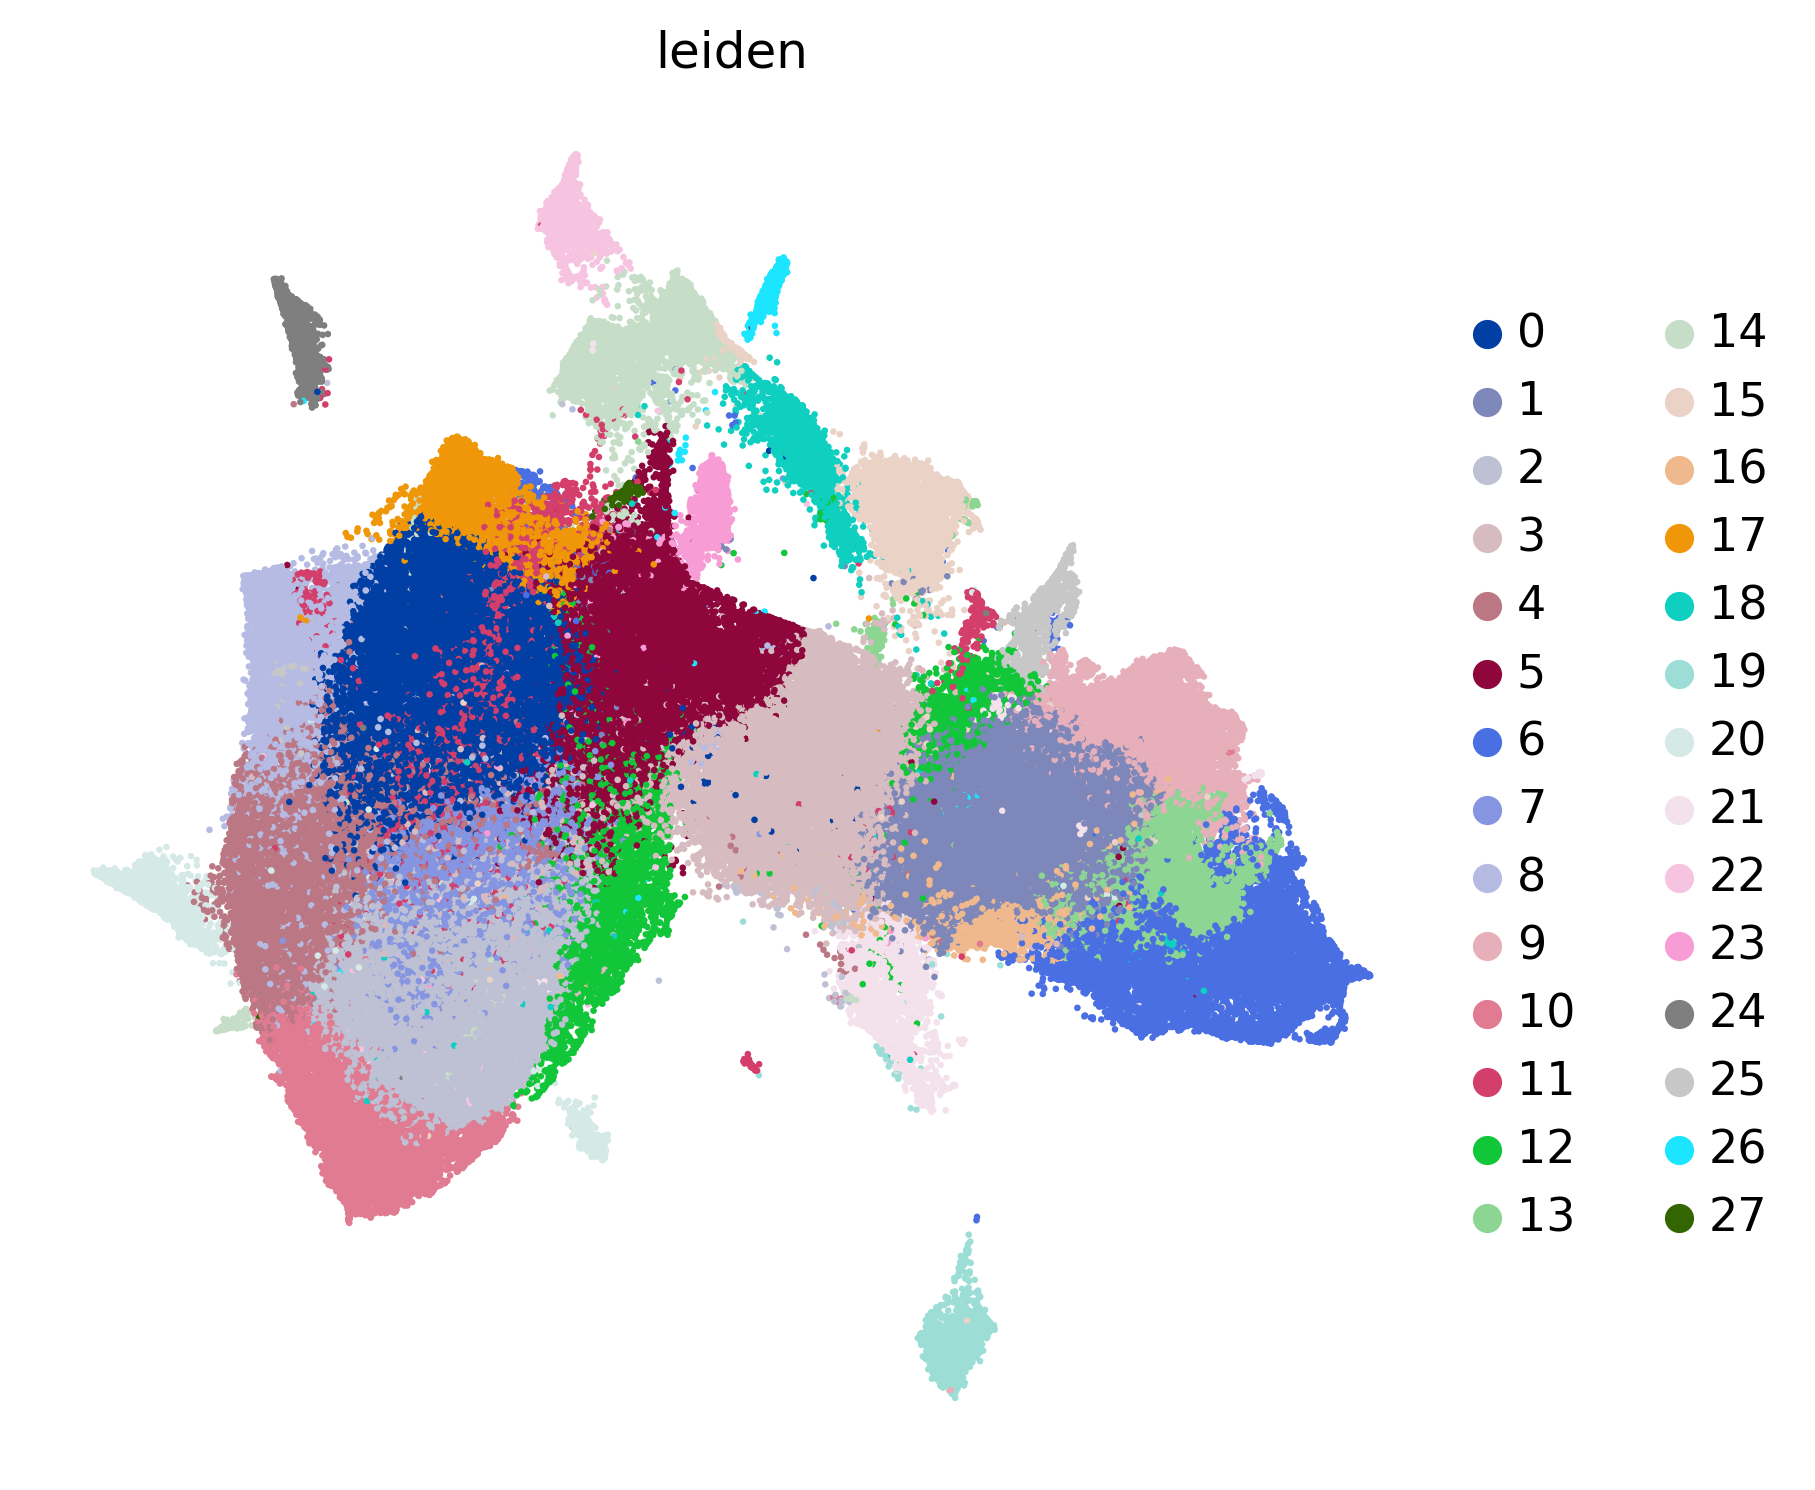

In [15]:
#LEIDEN UMAP
sc.pl.umap(data_ad, color='leiden', size=10)

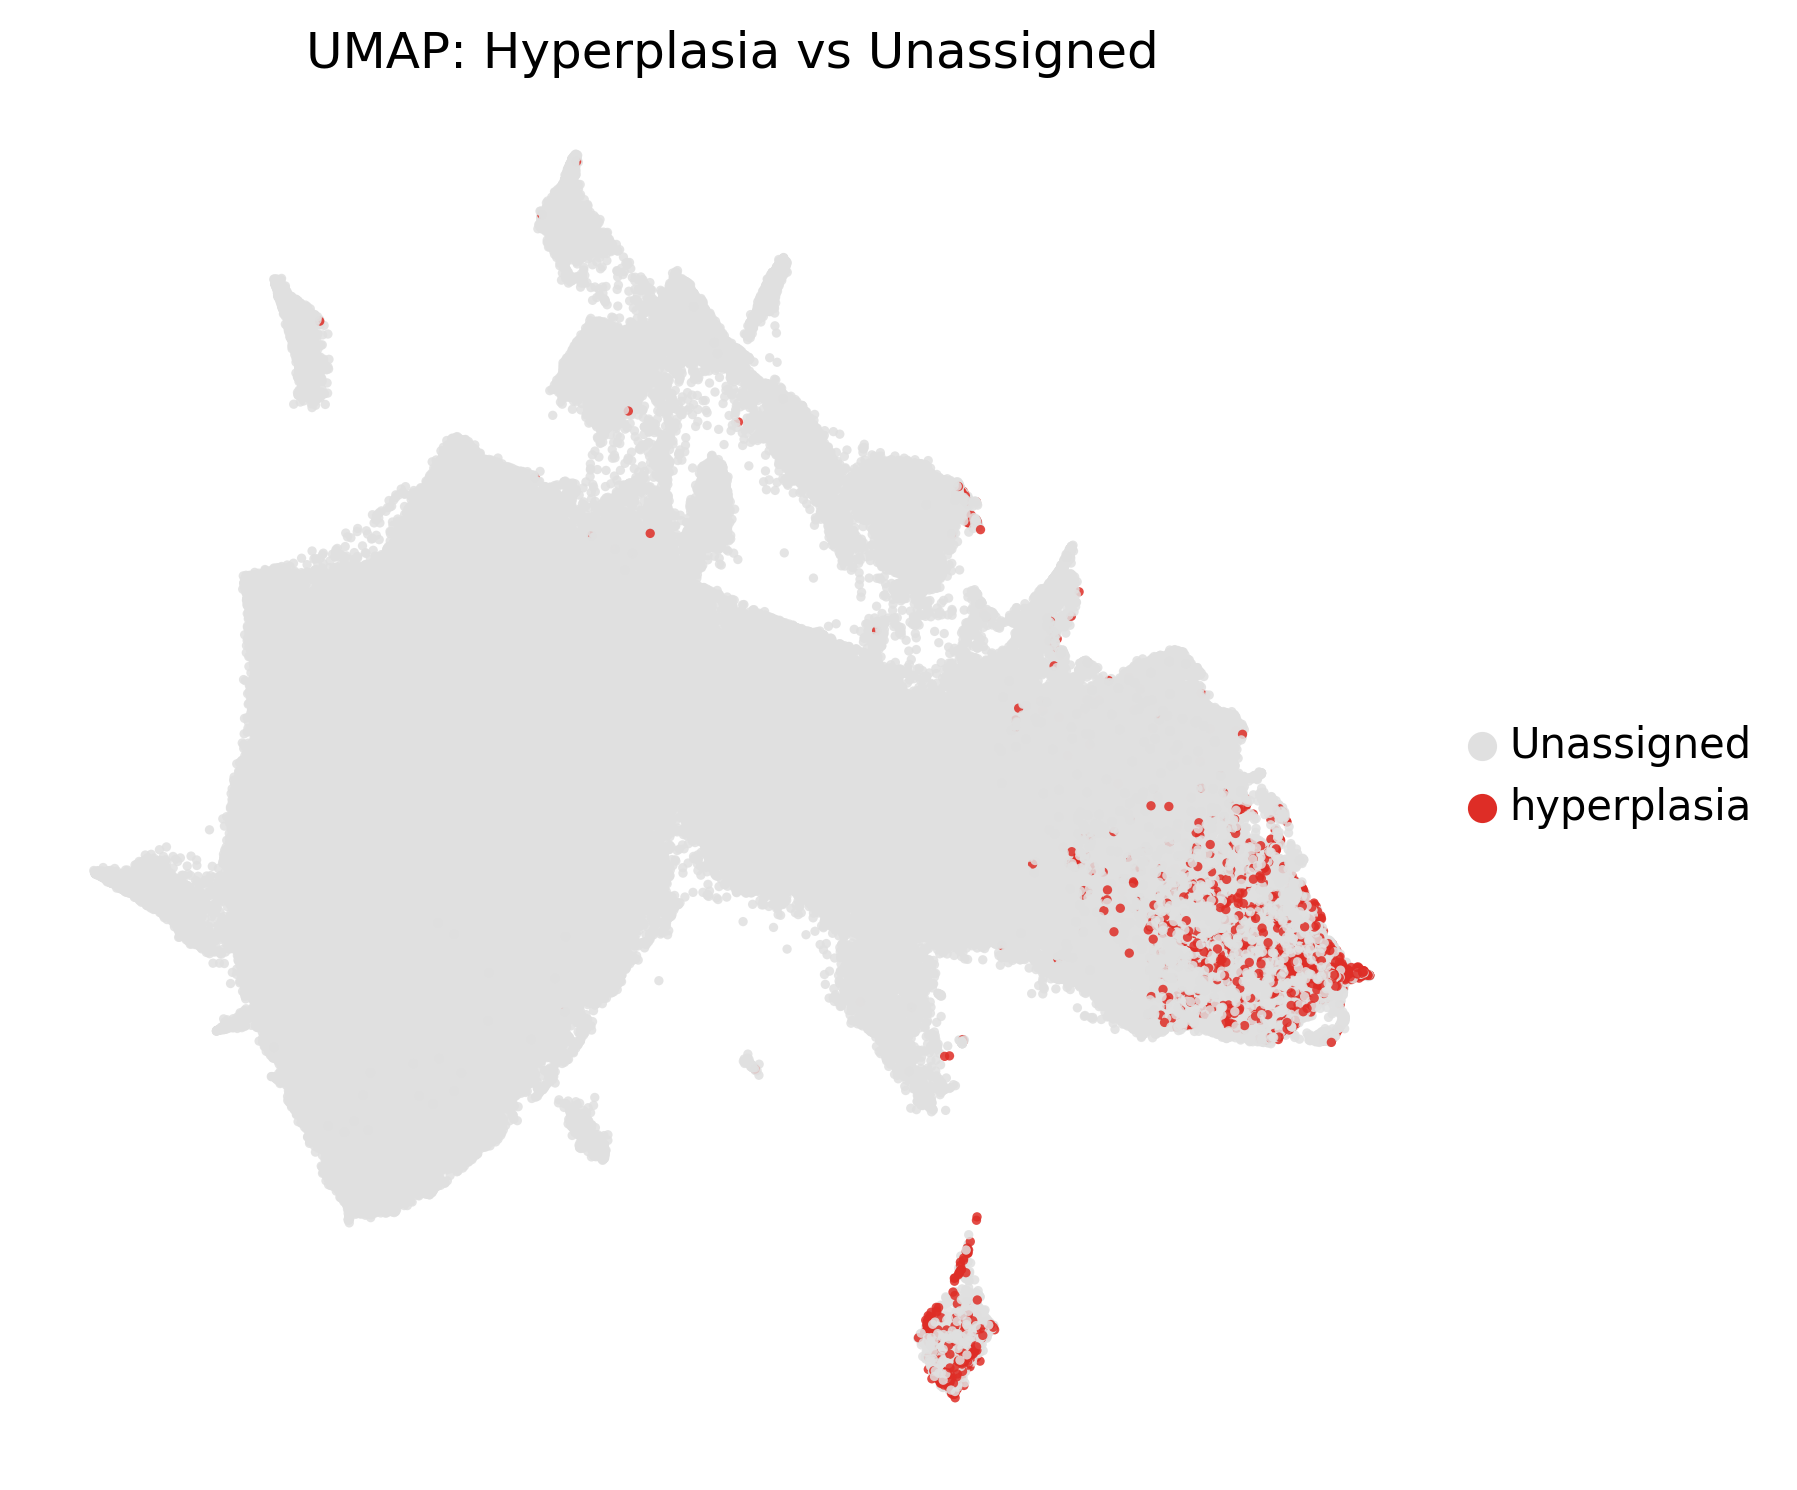

In [16]:
#ASSIGNMENT UMAP
import scanpy as sc
import matplotlib.pyplot as plt

# Custom color palette
custom_palette = {
    "Unassigned": "#e0e0e0",     # soft gray
    "hyperplasia": "#de2d26"     # bold red
}

# Plot UMAP
sc.pl.umap(
    data_ad,
    color="phenotypeSearch",
    palette=custom_palette,
    size=20,
    alpha=0.85,
    title="UMAP: Hyperplasia vs Unassigned",
    legend_loc="right margin",   # clean legend placement
    legend_fontsize=10,
    na_color="white",
    frameon=False,
    show=True
)

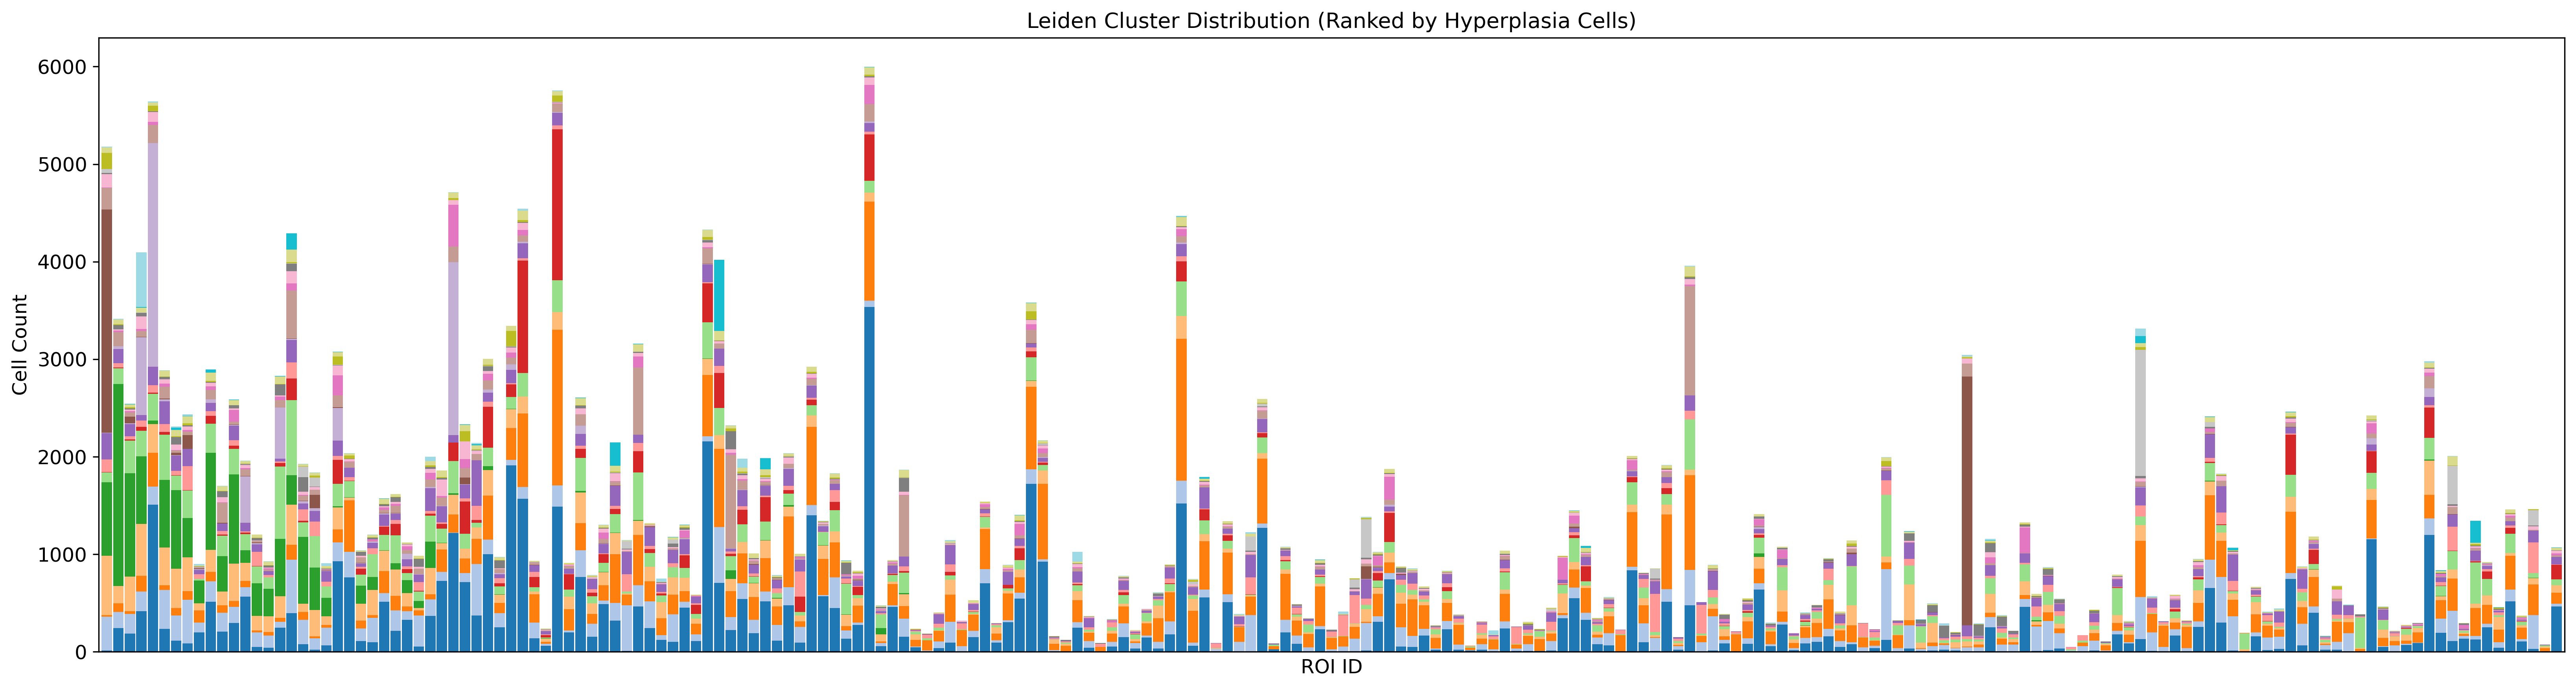

In [17]:
#STACKED BARPLOT
import pandas as pd
import matplotlib.pyplot as plt

# === Step 1: Extract and prepare data ===
df = data_ad.obs[['leiden', 'image', 'phenotypeSearch']].copy()

# Count hyperplasia cells per image
hyper_counts = df[df['phenotypeSearch'] == 'hyperplasia']['image'].value_counts()

# Include all images, even those with 0 hyperplasia cells
all_images = df['image'].unique()
full_counts = pd.Series(0, index=all_images)
full_counts.update(hyper_counts)

# Sort images by decreasing hyperplasia count
image_order = full_counts.sort_values(ascending=False).index

# Exclude the first image
image_order = image_order[1:]

# Count total cells per Leiden cluster
count_df = pd.crosstab(df['image'], df['leiden'])
count_df = count_df.loc[image_order]

# === Step 2: Plot ===
fig, ax = plt.subplots(figsize=(22, 6))
count_df.plot(kind='bar', stacked=True, ax=ax, width=0.9, colormap='tab20')

# === Step 3: Remove all x-axis ticks and labels ===
ax.set_xticks([])
ax.set_xticklabels([])
ax.tick_params(axis='x', bottom=False, labelbottom=False)

# === Step 4: Final styling ===
ax.set_xlabel("ROI ID")  # only axis label, no ticks
ax.set_ylabel("Cell Count")
ax.set_title("Leiden Cluster Distribution (Ranked by Hyperplasia Cells)", fontsize=13)
ax.grid(False)
ax.legend_.remove()

plt.tight_layout()
plt.show()

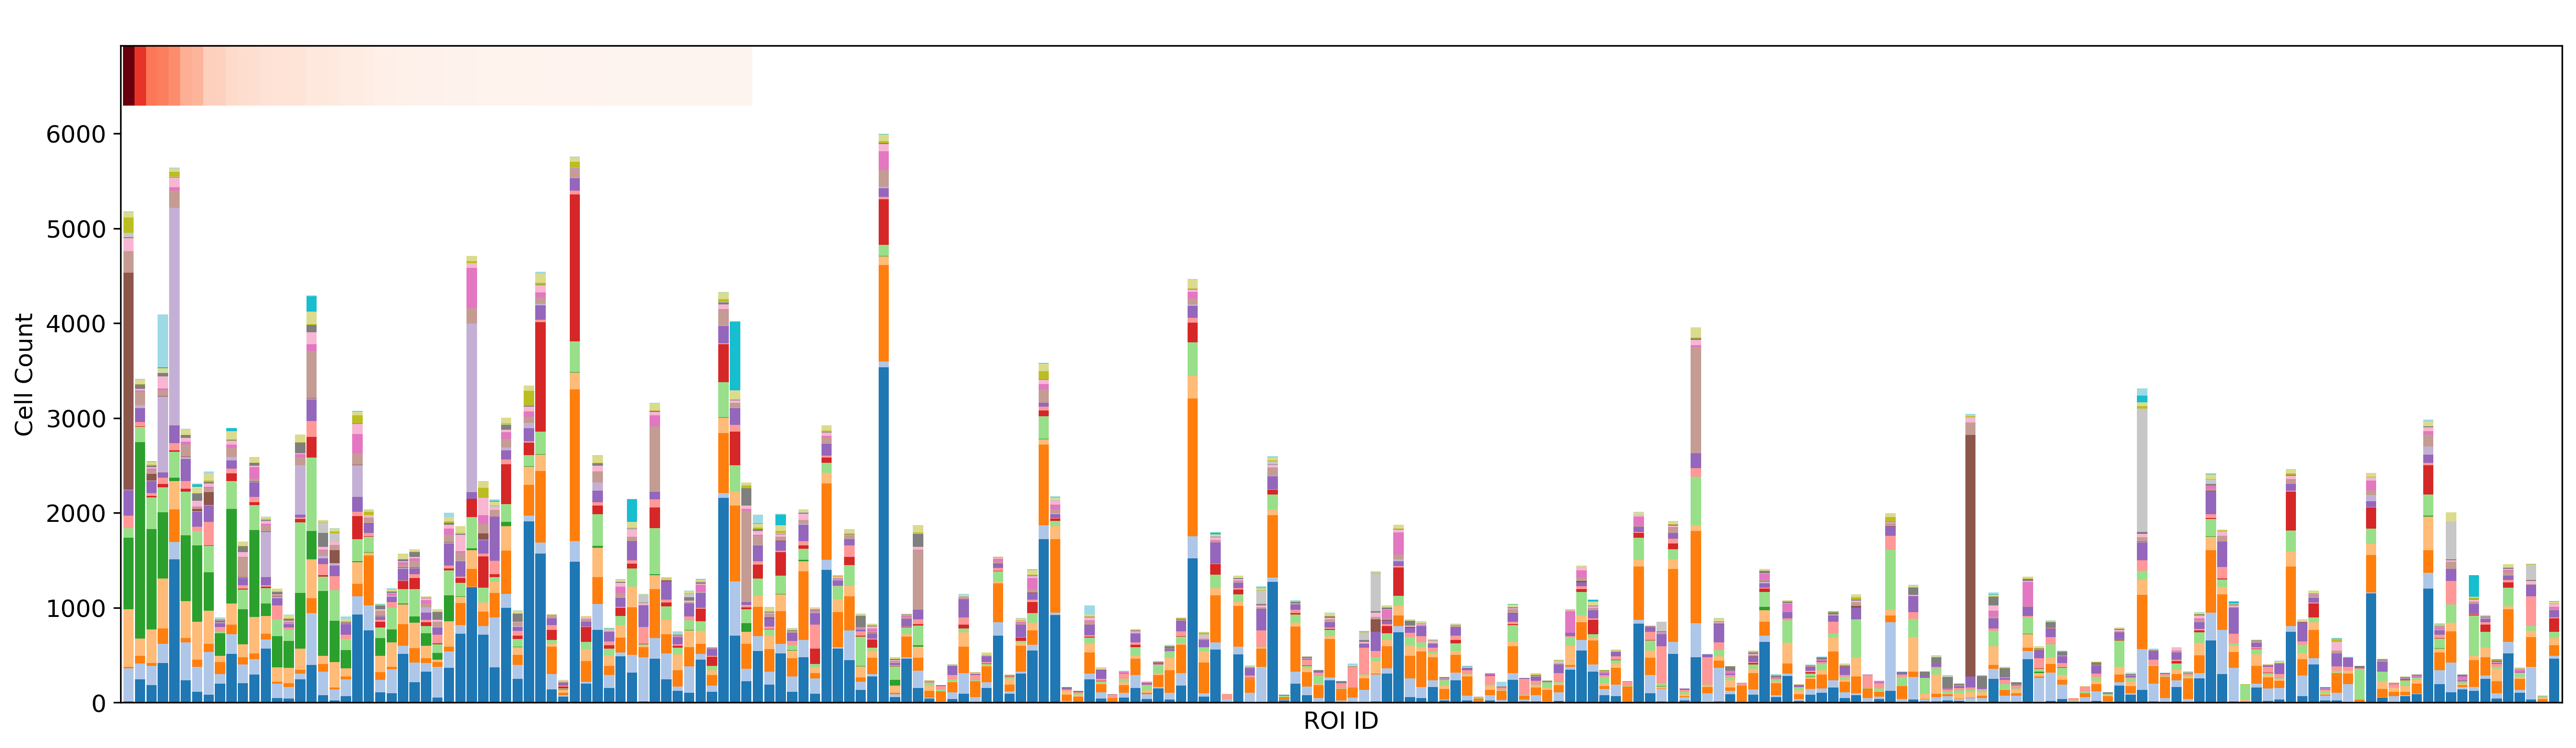

In [18]:
#STACKED BARPLOT WIHT ASSIGNED CELL COUNT 
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np

# === Prepare data ===
df = data_ad.obs[['leiden', 'image', 'phenotypeSearch']].copy()
hyper_counts = df[df['phenotypeSearch'] == 'hyperplasia']['image'].value_counts()
all_images = df['image'].unique()
full_counts = pd.Series(0, index=all_images)
full_counts.update(hyper_counts)
image_order = full_counts.sort_values(ascending=False).index[1:]
count_df = pd.crosstab(df['image'], df['leiden'])
count_df = count_df.loc[image_order]
hyper_values = full_counts.loc[image_order]

# === Custom colormap (0 = white) ===
reds = plt.colormaps.get_cmap('Reds')
colors = reds(np.linspace(0, 1, 256))
colors[0] = [1, 1, 1, 1]  # 0 = white
custom_cmap = mcolors.ListedColormap(colors)
norm = mcolors.Normalize(vmin=hyper_values.min(), vmax=hyper_values.max())
heat_colors = custom_cmap(norm(hyper_values.values))

# === Main plot ===
fig, ax = plt.subplots(figsize=(22, 6))
count_df.plot(kind='bar', stacked=True, ax=ax, width=0.9, colormap='tab20')

# Add heatmap strip above bars
n_bars = len(hyper_values)
xmin, xmax = -0.5, n_bars - 0.5
ymin, ymax = ax.get_ylim()
heat_height = (ymax - ymin) * 0.1
ax.imshow(
    heat_colors[np.newaxis, :, :],
    extent=[xmin, xmax, ymax, ymax + heat_height],
    aspect='auto',
    zorder=1
)
ax.set_ylim(ymin, ymax + heat_height)

# Final styling
ax.set_xticks([])
ax.set_xticklabels([])
ax.tick_params(axis='x', bottom=False, labelbottom=False)
ax.set_xlabel("ROI ID")
ax.set_ylabel("Cell Count")
ax.set_title(" ", fontsize=13)
ax.grid(False)
ax.legend_.remove()

plt.subplots_adjust(right=0.95)
plt.show()